In the segmentation part of the project, a deep learning model is used for the segmentation of road scene images. The CamVid dataset contains urban driving images and their corresponding pixel-level segmentation masks.

The objective is to train a segmentation model that assigns a class label to each pixel of the image, such as road, sky, building, tree, car, and other scene elements.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import zipfile
import cv2

from google.colab import drive

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Conv2DTranspose, concatenate
from tensorflow.keras.layers import Dropout, BatchNormalization

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Computer Vision Project/SegmentationDataset.zip'
extract_path = '/content/CamVidDataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

Mounted at /content/drive
['CamVid']


In [2]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    print(dirs)
    print('Number of files:', len(files))
    print('----------------')

/content/CamVidDataset
['CamVid']
Number of files: 0
----------------
/content/CamVidDataset/CamVid
['test', 'train', 'val_labels', 'val', 'train_labels', 'test_labels']
Number of files: 1
----------------
/content/CamVidDataset/CamVid/test
[]
Number of files: 232
----------------
/content/CamVidDataset/CamVid/train
[]
Number of files: 369
----------------
/content/CamVidDataset/CamVid/val_labels
[]
Number of files: 100
----------------
/content/CamVidDataset/CamVid/val
[]
Number of files: 100
----------------
/content/CamVidDataset/CamVid/train_labels
[]
Number of files: 369
----------------
/content/CamVidDataset/CamVid/test_labels
[]
Number of files: 232
----------------


In [3]:
train_path = '/content/CamVidDataset/CamVid/train'
train_mask_path = '/content/CamVidDataset/CamVid/train_labels'

val_path = '/content/CamVidDataset/CamVid/val'
val_mask_path = '/content/CamVidDataset/CamVid/val_labels'

test_path = '/content/CamVidDataset/CamVid/test'
test_mask_path = '/content/CamVidDataset/CamVid/test_labels'

The CamVid dataset consists of urban driving scenes together with pixel-level annotation masks. Each color in the mask corresponds to a different semantic class, such as road, building, sky, pedestrian, vehicle or vegetation.

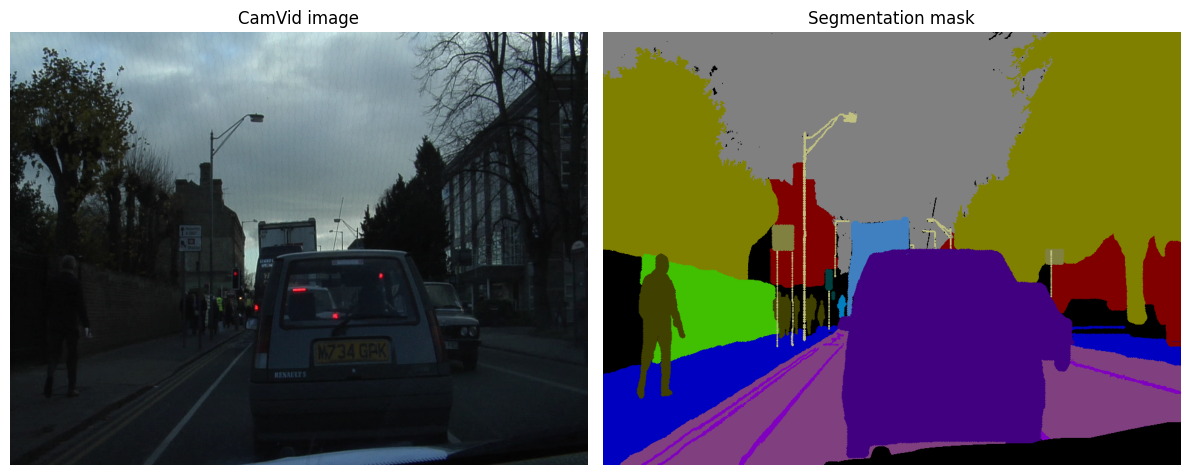

In [5]:
train_images = sorted(os.listdir(train_path))
train_masks = sorted(os.listdir(train_mask_path))

image = cv2.imread(os.path.join(train_path,
                                train_images[0]))

image = cv2.cvtColor(image,
                     cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(train_mask_path,
                               train_masks[0]))

mask = cv2.cvtColor(mask,
                    cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title('CamVid image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title('Segmentation mask')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
image = cv2.imread(os.path.join(train_path,
                                train_images[0]))

mask = cv2.imread(os.path.join(train_mask_path,
                               train_masks[0]))

print('Image shape:', image.shape)
print('Mask shape:', mask.shape)

Image shape: (720, 960, 3)
Mask shape: (720, 960, 3)


In [8]:
IMG_HEIGHT = 256
IMG_WIDTH = 256

The original CamVid masks are RGB images where each color represents a semantic class. Since the neural network cannot directly learn from RGB mask colors, each color has to be converted into an integer class label. The images and masks are also resized to 256×256 pixels to reduce training time while keeping enough spatial detail for segmentation.

In [10]:
all_colors = set()

for mask_name in train_masks:

    mask = cv2.imread(os.path.join(train_mask_path,
                                   mask_name))

    mask = cv2.cvtColor(mask,
                        cv2.COLOR_BGR2RGB)

    colors = np.unique(mask.reshape(-1,3),
                       axis=0)

    for color in colors:
        all_colors.add(tuple(color))

all_colors = sorted(list(all_colors))

print('Number of classes:', len(all_colors))

for i, color in enumerate(all_colors):
    print(i, color)

Number of classes: 31
0 (np.uint8(0), np.uint8(0), np.uint8(0))
1 (np.uint8(0), np.uint8(0), np.uint8(64))
2 (np.uint8(0), np.uint8(0), np.uint8(192))
3 (np.uint8(0), np.uint8(64), np.uint8(64))
4 (np.uint8(0), np.uint8(128), np.uint8(64))
5 (np.uint8(0), np.uint8(128), np.uint8(192))
6 (np.uint8(64), np.uint8(0), np.uint8(64))
7 (np.uint8(64), np.uint8(0), np.uint8(128))
8 (np.uint8(64), np.uint8(0), np.uint8(192))
9 (np.uint8(64), np.uint8(64), np.uint8(0))
10 (np.uint8(64), np.uint8(64), np.uint8(128))
11 (np.uint8(64), np.uint8(128), np.uint8(64))
12 (np.uint8(64), np.uint8(128), np.uint8(192))
13 (np.uint8(64), np.uint8(192), np.uint8(0))
14 (np.uint8(64), np.uint8(192), np.uint8(128))
15 (np.uint8(128), np.uint8(0), np.uint8(0))
16 (np.uint8(128), np.uint8(0), np.uint8(192))
17 (np.uint8(128), np.uint8(64), np.uint8(64))
18 (np.uint8(128), np.uint8(64), np.uint8(128))
19 (np.uint8(128), np.uint8(128), np.uint8(0))
20 (np.uint8(128), np.uint8(128), np.uint8(64))
21 (np.uint8(128),

In [11]:
color_map = {}

for i, color in enumerate(all_colors):
    color_map[color] = i

N_CLASSES = len(color_map)

print('Number of classes:', N_CLASSES)

Number of classes: 31


In [12]:
def load_image(path):

    image = cv2.imread(path)

    image = cv2.cvtColor(image,
                         cv2.COLOR_BGR2RGB)

    image = cv2.resize(image,
                       (IMG_WIDTH, IMG_HEIGHT))

    image = image.astype(np.float32) / 255.0

    return image

In [13]:
def load_mask(path):

    mask = cv2.imread(path)

    mask = cv2.cvtColor(mask,
                        cv2.COLOR_BGR2RGB)

    mask = cv2.resize(mask,
                      (IMG_WIDTH, IMG_HEIGHT),
                      interpolation=cv2.INTER_NEAREST)

    label_mask = np.zeros((IMG_HEIGHT,
                           IMG_WIDTH),
                          dtype=np.uint8)

    for color, index in color_map.items():

        matches = np.all(mask == color,
                         axis=-1)

        label_mask[matches] = index

    return label_mask

In [14]:
image = load_image(os.path.join(train_path,
                                train_images[0]))

mask = load_mask(os.path.join(train_mask_path,
                              train_masks[0]))

print(image.shape)
print(mask.shape)

print('Min label:', np.min(mask))
print('Max label:', np.max(mask))

(256, 256, 3)
(256, 256)
Min label: 0
Max label: 30


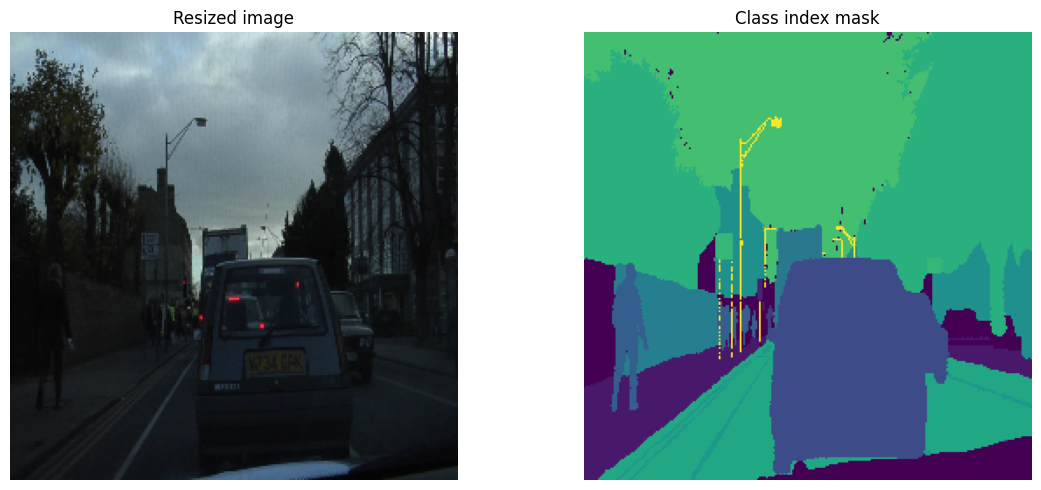

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Resized image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title('Class index mask')
plt.axis('off')

plt.tight_layout()
plt.show()

The visualization shows that the preprocessing keeps the correspondence between the input image and the segmentation mask. The image is normalized for training, while the mask is represented as a class-index image where each pixel contains the label of its semantic class.

In [16]:
X_train = []
Y_train = []

for image_name, mask_name in zip(train_images,
                                 train_masks):

    image = load_image(os.path.join(train_path,
                                    image_name))

    mask = load_mask(os.path.join(train_mask_path,
                                  mask_name))

    X_train.append(image)
    Y_train.append(mask)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

print(X_train.shape)
print(Y_train.shape)

(369, 256, 256, 3)
(369, 256, 256)


In [17]:
val_images = sorted(os.listdir(val_path))
val_masks = sorted(os.listdir(val_mask_path))

X_val = []
Y_val = []

for image_name, mask_name in zip(val_images,
                                 val_masks):

    image = load_image(os.path.join(val_path,
                                    image_name))

    mask = load_mask(os.path.join(val_mask_path,
                                  mask_name))

    X_val.append(image)
    Y_val.append(mask)

X_val = np.array(X_val)
Y_val = np.array(Y_val)

print(X_val.shape)
print(Y_val.shape)

(100, 256, 256, 3)
(100, 256, 256)


In [18]:
test_images = sorted(os.listdir(test_path))
test_masks = sorted(os.listdir(test_mask_path))

X_test = []
Y_test = []

for image_name, mask_name in zip(test_images,
                                 test_masks):

    image = load_image(os.path.join(test_path,
                                    image_name))

    mask = load_mask(os.path.join(test_mask_path,
                                  mask_name))

    X_test.append(image)
    Y_test.append(mask)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

print(X_test.shape)
print(Y_test.shape)

(232, 256, 256, 3)
(232, 256, 256)


In [19]:
unique_labels = np.unique(Y_train)

print('Number of classes in training masks:',
      len(unique_labels))

print(unique_labels)

Number of classes in training masks: 31
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]


A U-Net model is used to segment the images. The network first extracts information from the input image and then uses this information to generate a pixel-level segmentation mask. Additional connections between layers help retain important details and improve accuracy.

In [20]:
def conv_block(input_layer, n_filters):

    x = Conv2D(n_filters, (3, 3), activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)

    x = Conv2D(n_filters, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    return x

In [21]:
def build_unet(input_shape, n_classes):

    inputs = Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = MaxPooling2D((2, 2))(c4)
    p4 = Dropout(0.3)(p4)

    c5 = conv_block(p4, 512)

    u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = conv_block(u6, 256)

    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = conv_block(u7, 128)

    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = conv_block(u8, 64)

    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = conv_block(u9, 32)

    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])

    return model

In [22]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

model = build_unet(input_shape, N_CLASSES)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 7,772,863 (29.65 MB)

 Trainable params: 7,766,975 (29.63 MB)

 Non-trainable params: 5,888 (23.00 KB)

The U-Net model is trained using the training set and evaluated on the validation set after each epoch. Our objective is to minimize the segmentation loss while maximizing the classification accuracy.

In [25]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=35,
    batch_size=8
)

Epoch 1/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.8522 - loss: 0.5131 - val_accuracy: 0.8209 - val_loss: 0.6110
Epoch 2/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.8537 - loss: 0.5016 - val_accuracy: 0.8522 - val_loss: 0.5345
Epoch 3/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.8626 - loss: 0.4727 - val_accuracy: 0.8472 - val_loss: 0.5412
Epoch 4/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.8580 - loss: 0.4831 - val_accuracy: 0.8237 - val_loss: 0.6234
Epoch 5/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.8542 - loss: 0.4965 - val_accuracy: 0.7570 - val_loss: 0.8835
Epoch 6/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.8561 - loss: 0.4933 - val_accuracy: 0.8464 - val_loss: 0.5444
Epoch 7/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.8604 - loss: 0.4737 - val_accuracy: 0.8601 - val_loss: 0.5163
Epoch 8/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.8702 - loss: 0.4371 - val_accuracy: 0.

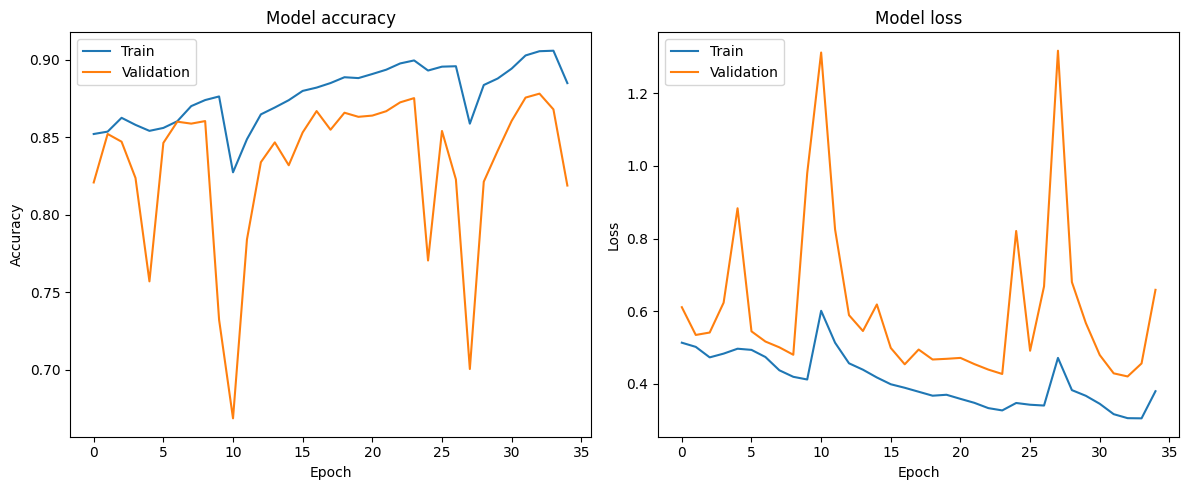

In [27]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()

The U-Net model converged after approximately 30 epochs. The best validation accuracy achieved was around 88%, indicating that the model learned meaningful semantic representations despite the large number of classes present in the dataset. Some fluctuations were observed in the validation accuracy, which can be attributed to the complexity of the segmentation task and the relatively small validation set.

In [26]:
test_score = model.evaluate(X_test,
                            Y_test)

print('Test loss = {}'.format(test_score[0]))
print('Test accuracy = {}'.format(test_score[1]))

8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 198ms/step - accuracy: 0.7338 - loss: 1.0281
Test loss = 1.0280542373657227
Test accuracy = 0.7338151335716248


The trained model is now evaluated on unseen test images. The predicted segmentation masks are compared with the ground truth in order to visually assess the quality of the segmentation.

In [28]:
predictions = model.predict(X_test)

predicted_masks = np.argmax(predictions,
                            axis=-1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 681ms/step


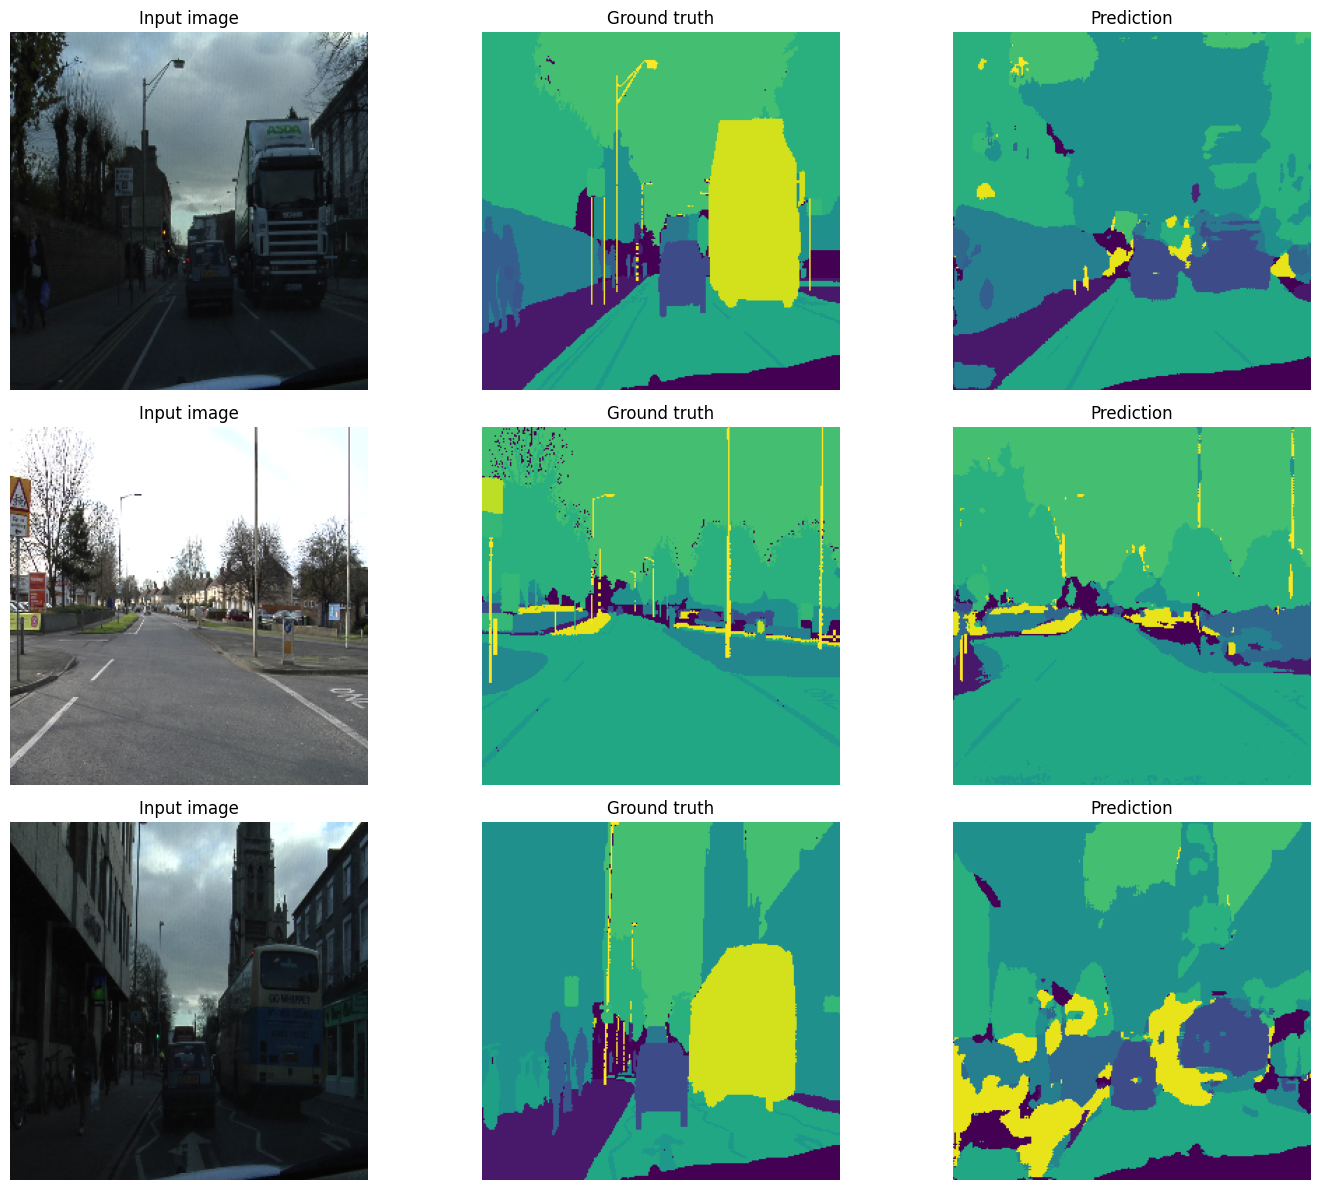

In [29]:
import random

indices = random.sample(range(len(X_test)), 3)

plt.figure(figsize=(15,12))

for row, i in enumerate(indices):

    plt.subplot(3,3,3*row+1)
    plt.imshow(X_test[i])
    plt.title('Input image')
    plt.axis('off')

    plt.subplot(3,3,3*row+2)
    plt.imshow(Y_test[i])
    plt.title('Ground truth')
    plt.axis('off')

    plt.subplot(3,3,3*row+3)
    plt.imshow(predicted_masks[i])
    plt.title('Prediction')
    plt.axis('off')

plt.tight_layout()
plt.show()

As it can be seen, the predicted segmentation masks more or less successfully capture the main semantic regions of the scene, including roads, buildings, vegetation and sky. The model is also capable of identifying larger vehicles and urban structures. Most segmentation errors occur around object boundaries and small classes such as pedestrians, poles and traffic signs. Despite these limitations, the predicted masks preserve the overall scene layout and demonstrate that the U-Net model learned meaningful semantic representations of urban environments.